# ENTSO-E Prices Explorer (A44) — Parquet

This notebook:
- Sets token/zone/time
- Uses `scripts/entsoe_daily_update.py` to fetch prices
- Stores data in a partitioned Parquet dataset under `data/entsoe/parquet`
- Loads and plots data without re-hitting the API

Notes:
- Time format: UTC `yyyyMMddHHmm`.
- `CONTRACT`: `A01`=Day-ahead, `A07`=Intraday.
- Token comes from `ENTSOE_TOKEN` or set `TOKEN` below.

In [1]:
# Optional: ensure dependencies for exploration
%pip -q install pandas pyarrow matplotlib

Note: you may need to restart the kernel to use updated packages.


## Batch Fetch 2019–2025 (monthly) — Parquet

In [ ]:
import sys, subprocess, pathlib, datetime as dt, time, shlex, pathlib, os

# --- Parameters ---
TOKEN = '48f6a78d-a3fd-4b4c-b458-301f76850c5c'  # e.g., 'YOUR_SECURITY_TOKEN'
ZONE = '10YNL----------L'  # Netherlands by default
OUT_ZONE = None
CONTRACT = 'A01'

BATCH_START_YEAR = 2025
BATCH_END_YEAR   = 2025  # inclusive

PARQUET_DIR = r'parquet'
COUNTRY_TAG = 'NL'

# Try to anchor relative paths to the repo root (folder containing 'scripts')

def find_repo_root():
    p = pathlib.Path.cwd()
    for q in [p, *p.parents]:
        if (q / 'energy_price_data' / 'entsoe_daily_update.py').exists() or (q / '.git').exists():
            return q
    return pathlib.Path.cwd()
REPO_ROOT = find_repo_root()
if not os.path.isabs(PARQUET_DIR):
    PARQUET_DIR = str((REPO_ROOT / PARQUET_DIR).resolve())
OUTPUT_PARQUET = str((REPO_ROOT / 'energy_price_data' / f'entsoe_prices1_{COUNTRY_TAG}.parquet').resolve())

REPO_ROOT = find_repo_root()

script = (REPO_ROOT / 'energy_price_data' / 'entsoe_daily_update.py').resolve()
assert script.exists(), f'Cannot find script: {script}'

def ym_start_end(y, m):
    start = dt.datetime(y, m, 1, 0, 0)
    end = dt.datetime(y+1, 1, 1, 0, 0) if m==12 else dt.datetime(y, m+1, 1, 0, 0)
    return start.strftime('%Y%m%d%H%M'), end.strftime('%Y%m%d%H%M')

for year in range(BATCH_START_YEAR, BATCH_END_YEAR+1):
    for month in range(1, 13):
        s,e = ym_start_end(year, month)
        cmd = [sys.executable, str(script), '--zone', ZONE, '--start', s, '--end', e, '--contract', CONTRACT, '--parquet-dir', PARQUET_DIR]
        if OUT_ZONE: cmd += ['--out_Domain', OUT_ZONE]
        if TOKEN: cmd += ['--token', TOKEN]
        print(f'Running {year}-{month:02d}:', ' '.join([shlex.quote(c) for c in cmd]))
        res = subprocess.run(cmd, text=True, capture_output=True)
        if res.returncode != 0:
            print(res.stdout); print(res.stderr)
            raise RuntimeError(f'Fetch failed {year}-{month:02d} with code {res.returncode}')
        else:
            line = next((ln for ln in res.stdout.splitlines() if ln.startswith('Parsed ')), '')
            print('OK', line)
        time.sleep(0.3)
print('Batch done.')


Running 2025-01: 'c:\Users\20203525\AppData\Local\anaconda3\python.exe' 'C:\Users\20203525\Documents\2025 2026\WB4U\energy-profile-HEMS\energy_price_data\entsoe_daily_update.py' --zone 10YNL----------L --start 202501010000 --end 202502010000 --contract A01 --parquet-dir 'C:\Users\20203525\Documents\2025 2026\WB4U\energy-profile-HEMS\backend\data\entsoe\parquet' --token 48f6a78d-a3fd-4b4c-b458-301f76850c5c
OK Parsed 767 price points
Running 2025-02: 'c:\Users\20203525\AppData\Local\anaconda3\python.exe' 'C:\Users\20203525\Documents\2025 2026\WB4U\energy-profile-HEMS\energy_price_data\entsoe_daily_update.py' --zone 10YNL----------L --start 202502010000 --end 202503010000 --contract A01 --parquet-dir 'C:\Users\20203525\Documents\2025 2026\WB4U\energy-profile-HEMS\backend\data\entsoe\parquet' --token 48f6a78d-a3fd-4b4c-b458-301f76850c5c
OK Parsed 692 price points
Running 2025-03: 'c:\Users\20203525\AppData\Local\anaconda3\python.exe' 'C:\Users\20203525\Documents\2025 2026\WB4U\energy-profi

## Build single-file Parquet (country-tagged)
Combines all partitions under `PARQUET_DIR` into one file named `entsoe_prices_<COUNTRY_TAG>.parquet` in the `data/entsoe` folder.
It appends/deduplicates on `(bidding_zone, contract, ts_utc)` and sorts by time.

In [6]:
import os, pandas as pd, pathlib

def load_all_partitions(root: str):
    files = list(pathlib.Path(root).rglob('*.parquet'))
    if not files:
        return pd.DataFrame(columns=['bidding_zone','contract','ts_utc','price','currency','unit','resolution','year','month'])
    frames = []
    for f in files:
        try:
            frames.append(pd.read_parquet(f))
        except Exception:
            pass
    if not frames:
        return pd.DataFrame()
    df_all = pd.concat(frames, ignore_index=True)
    df_all['ts_utc'] = pd.to_datetime(df_all['ts_utc'], utc=True)
    return df_all

os.makedirs(os.path.dirname(OUTPUT_PARQUET), exist_ok=True)
df_all_parts = load_all_partitions(PARQUET_DIR)
if os.path.exists(OUTPUT_PARQUET):
    try:
        df_existing = pd.read_parquet(OUTPUT_PARQUET)
        df_existing['ts_utc'] = pd.to_datetime(df_existing['ts_utc'], utc=True)
    except Exception:
        df_existing = pd.DataFrame()
else:
    df_existing = pd.DataFrame()

df_out = pd.concat([df_existing, df_all_parts], ignore_index=True) if not df_all_parts.empty else df_existing.copy()
if not df_out.empty:
    df_out = df_out.drop_duplicates(subset=['bidding_zone','contract','ts_utc'], keep='last')
    df_out = df_out.sort_values('ts_utc')
    df_out.to_parquet(OUTPUT_PARQUET, index=False)
print(f'Wrote consolidated file: {OUTPUT_PARQUET}')
print(f'Rows in consolidated file: {0 if ("df_out" not in globals()) or df_out is None or df_out.empty else len(df_out)}')

Wrote consolidated file: C:\Users\20203525\Documents\2025 2026\WB4U\energy-profile-HEMS\energy_price_data\entsoe_prices1_NL.parquet
Rows in consolidated file: 15378


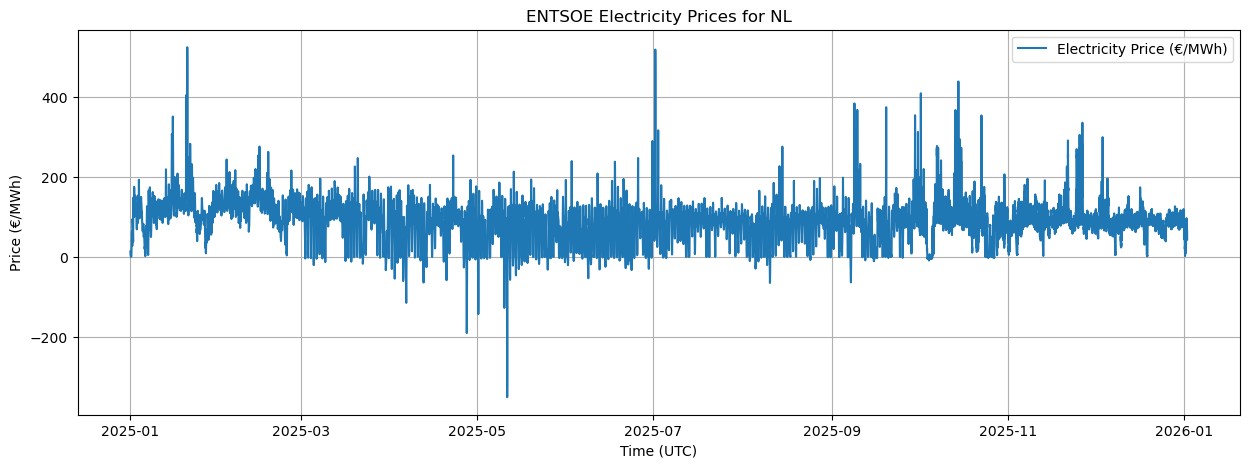

In [7]:
#TODO: plot timeseries of entsoe_prices1_NL.parquet
#!/usr/bin/env python3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pathlib
import os
# Load the consolidated Parquet file
COUNTRY_TAG = 'NL'
PARQUET_FILE = f'entsoe_prices1_{COUNTRY_TAG}.parquet'
# --- IGNORE ---
REPO_ROOT = find_repo_root()
PARQUET_PATH = REPO_ROOT / 'energy_price_data' / PARQUET_FILE
df = pd.read_parquet(PARQUET_PATH)
# Ensure the timestamp is in datetime format
df['ts_utc'] = pd.to_datetime(df['ts_utc'], utc=True)
# Plot the price time series
plt.figure(figsize=(15, 5))
plt.plot(df['ts_utc'], df['price'], label='Electricity Price (€/MWh)')
plt.xlabel('Time (UTC)')
plt.ylabel('Price (€/MWh)')
plt.title(f'ENTSOE Electricity Prices for {COUNTRY_TAG}')
plt.legend()
plt.grid(True)
plt.show()

In [8]:
df.head()

,ts_utc,price,currency,unit,resolution,document_mrid,bidding_zone,contract,year,month
0,2024-12-31 23:00:00+00:00,13.62,EUR,MWH,PT60M,4b7a682dc7e24e9094806098d7374256,10YNL----------L,A01,2024,12
1,2025-01-01 00:00:00+00:00,6.24,EUR,MWH,PT60M,4b7a682dc7e24e9094806098d7374256,10YNL----------L,A01,2025,1
2,2025-01-01 01:00:00+00:00,4.16,EUR,MWH,PT60M,4b7a682dc7e24e9094806098d7374256,10YNL----------L,A01,2025,1
3,2025-01-01 02:00:00+00:00,3.28,EUR,MWH,PT60M,4b7a682dc7e24e9094806098d7374256,10YNL----------L,A01,2025,1
4,2025-01-01 03:00:00+00:00,0.68,EUR,MWH,PT60M,4b7a682dc7e24e9094806098d7374256,10YNL----------L,A01,2025,1
